# **EQ03 — Vol locale vs Heston : même calibration, prix d'exotique différent**

**Le capstone.** On calibre **deux** modèles — vol locale de Dupire (nb 06) et Heston
(nb 05) — sur **exactement la même** surface de vanilles. Les deux **repricent les
vanilles**. Pourtant, sur un **exotique**, ils donnent des prix **différents**.

> **Thèse — risque de modèle.** Calibrer sur les vanilles ne suffit pas : deux modèles
> indistinguables sur les options européennes peuvent diverger sur un payoff
> path-dependent, car ils n'ont pas la **même dynamique de smile**.

Le fil :
1. **Cohérence** : LV et Heston repricent la même surface.
2. **Divergence** : un call **à barrière** (up-and-out) vaut un prix différent sous
   chaque modèle ; une **digitale**, elle, est ~identique (payoff européen sensible au
   seul skew d'aujourd'hui).
3. **Le pourquoi** : quand le spot bouge, le smile **ne se déplace pas pareil** —
   *sticky-strike* vs *sticky-moneyness* vs dynamique de la **vol locale**.

In [1]:
from datetime import date, timedelta

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from JR_PRICER.market_data.quote import Quote
from JR_PRICER.market_data.underlying import Underlying
from JR_PRICER.utils.day_count import DayCounter
from JR_PRICER.utils.frequency import Frequency

from JR_PRICER.curves.temporal.discount import FlatDiscountCurve
from JR_PRICER.curves.forward.analytic_forward import AnalyticForwardCurve

from JR_PRICER.instruments.derivatives.equity.base import OptionType
from JR_PRICER.instruments.derivatives.equity.european_option import EuropeanOption
from JR_PRICER.instruments.derivatives.equity.barrier_option import (
    BarrierOption, BarrierType, BarrierDirection,
)

from JR_PRICER.pricing.model.heston import HestonModel
from JR_PRICER.pricing.model.local_vol import LocalVolModel
from JR_PRICER.pricing.engine.fourier_carr_madan import FourierCarrMadanEngine
from JR_PRICER.pricing.model.discretization.CIR.base import (
    CIRDiscretizationSchemeEuler, EulerDiscretizationConvention,
)
from JR_PRICER.pricing.model.calibration.cost_function.implied_vol_calculator import ImpliedVolCalculator
from JR_PRICER.pricing.model.calibration.cost_function.implied_vol_cost import ImpliedVolErrorCost
from JR_PRICER.pricing.model.calibration.optimizer.scipy_ols_optimizer import SciPyOLSOptimizer
from JR_PRICER.pricing.model.calibration.base import calibrate

from JR_PRICER.curves.vol_smile.volsmile import VolSmile
from JR_PRICER.curves.vol_smile.moneyness_convention import AbsoluteStrike
from JR_PRICER.surfaces.vol_surface.volsurface import VolSurface
from JR_PRICER.surfaces.vol_surface.interpolators_2D.SVI import SVIInterpolator
from JR_PRICER.curves.interpolators_1D.log_linear import LogLinearInterpolator1D

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
C_LV, C_HE, C_MKT, C_SK = '#E65100', '#1565C0', '#C62828', '#2E7D32'
print('Imports OK')

Imports OK


## 0. Le marché, et les deux modèles calibrés dessus

Surface de vanilles générée par le Heston vrai. On **calibre Heston** (Fourier, qui
retrouve les paramètres vrais) et on **construit la vol locale** (SVI → Dupire) sur la
**même** surface.

In [2]:
REF = date(2024, 1, 15)
DC = DayCounter('act/365')
def in_days(n): return REF + timedelta(days=int(n))

S0, R = 100.0, 0.03
spot0 = Quote(S0, name='EQ')
disc = FlatDiscountCurve(R, DC, REF)
fwd0 = AnalyticForwardCurve(spot0, disc, dividend_yield=0.0)
und0 = Underlying('EQ', spot0, fwd0, vol_provider=None)

TRUE = dict(kappa=1.5, theta=0.04, sigma_v=0.5, rho=-0.7, v0=0.035)
heston_true = HestonModel(discount_curve=disc, **TRUE)
fourier = FourierCarrMadanEngine(alpha=1.5, n=12, eta=0.25)
ivc = ImpliedVolCalculator(disc)

# --- Surface de marché (smiles SVI en AbsoluteStrike) ---
surf_days = [91, 182, 365, 730, 1095]
strikes = np.linspace(60, 160, 25)
smiles = []
for d in surf_days:
    cs = [EuropeanOption(und0, float(K), REF, in_days(d), OptionType.CALL) for K in strikes]
    iv = ivc.calculate_implied_vol(cs, fourier.price(cs, heston_true))
    smiles.append(VolSmile(strikes, iv, LogLinearInterpolator1D(), in_days(d), AbsoluteStrike()))
surface = VolSurface(smiles, REF, DC, SVIInterpolator(fwd0), forward_curve=fwd0)
surface.calibrate_interpolator()
und0.vol_provider = surface

# --- Modèle 1 : Heston calibré sur la surface ---
cal_strikes = np.linspace(80, 125, 9)
cal_instr = [EuropeanOption(und0, float(K), REF, in_days(d), OptionType.CALL)
             for d in surf_days for K in cal_strikes]
cal_ivs = np.asarray(ivc.calculate_implied_vol(cal_instr, fourier.price(cal_instr, heston_true)))
cost = ImpliedVolErrorCost(cal_instr, cal_ivs, fourier, disc, HestonModel)
heston = calibrate(SciPyOLSOptimizer(), cost,
                   np.array([1.0, 0.05, 0.40, -0.30, 0.04]),
                   ([0.05, 0.005, 0.05, -0.999, 0.005], [10, 0.5, 2, 0.999, 0.5]))

# --- Modèle 2 : vol locale de Dupire sur la même surface ---
lv = LocalVolModel(disc)

print('Heston calibré :', {k: round(v, 4) for k, v in
      dict(kappa=heston.kappa, theta=heston.theta, sigma_v=heston.sigma_v,
           rho=heston.rho, v0=heston.v0).items()})
print('Vol locale     :', lv)

Heston calibré : {'kappa': np.float64(1.5), 'theta': np.float64(0.04), 'sigma_v': np.float64(0.5), 'rho': np.float64(-0.7), 'v0': np.float64(0.035)}
Vol locale     : LocalVolModel(discount=FlatDiscountCurve(rate=0.03, ref=2024-01-15))


In [3]:
# Outillage : un payoff = S_T (par chemin) permet de repricer TOUS les strikes
# d'UNE seule simulation. La grille dense est nécessaire à la diffusion à vol locale ;
# pour Heston (n_steps=1) le modèle densifie lui-même via discretize(max_dt).
class TerminalSpots(EuropeanOption):
    def __init__(self, *a, n_steps=120, **k):
        super().__init__(*a, **k); self._n = n_steps
    def simulation_times(self, ref, dc):
        T = dc.year_fraction(ref, self.maturity_date)
        return list(np.linspace(T/self._n, T, self._n))
    def payoff(self, paths):
        return paths[:, -1]

class FrozenLV(LocalVolModel):
    # Vol locale FIGÉE aujourd'hui en (K,t) absolu : on capture surface et forward
    # du jour, indépendamment du spot de diffusion (qui ne fixe que S_0).
    def __init__(self, disc, surf0, fwd_today):
        super().__init__(disc); self._surf0 = surf0; self._fwd0 = fwd_today
    def sigma_loc(self, S, t, vol_surface, forward_curve):
        return super().sigma_loc(S, t, self._surf0, self._fwd0)

FT = EulerDiscretizationConvention.FULL_TRUNCATION
def heston_mc(max_dt):
    return heston.discretize(CIRDiscretizationSchemeEuler(FT), max_dt=max_dt)

def terminal_ST(model, underlying, mat_days, n_paths, n_steps, seed):
    # Vecteur S_T (par chemin) à la maturité, d'UNE simulation.
    ts = TerminalSpots(underlying, S0, REF, in_days(mat_days), OptionType.CALL, n_steps=n_steps)
    df = disc.discount(mat_days/365.0)
    return model.simulate(ts, n_paths, rng=np.random.default_rng(seed)) / df

print('Helpers prêts')

Helpers prêts


## 1. Cohérence : les deux modèles repricent les vanilles

Heston (Fourier, exact) et la vol locale (MC) reproduisent le **même** smile de marché.
La vol locale est repricée d'**une seule simulation** : on diffuse $S_T$, puis on
valorise tous les strikes en vectoriel. Le léger résidu LV est l'artefact d'extraction
vu au nb 06 — petit devant les écarts d'exotique qui suivent.

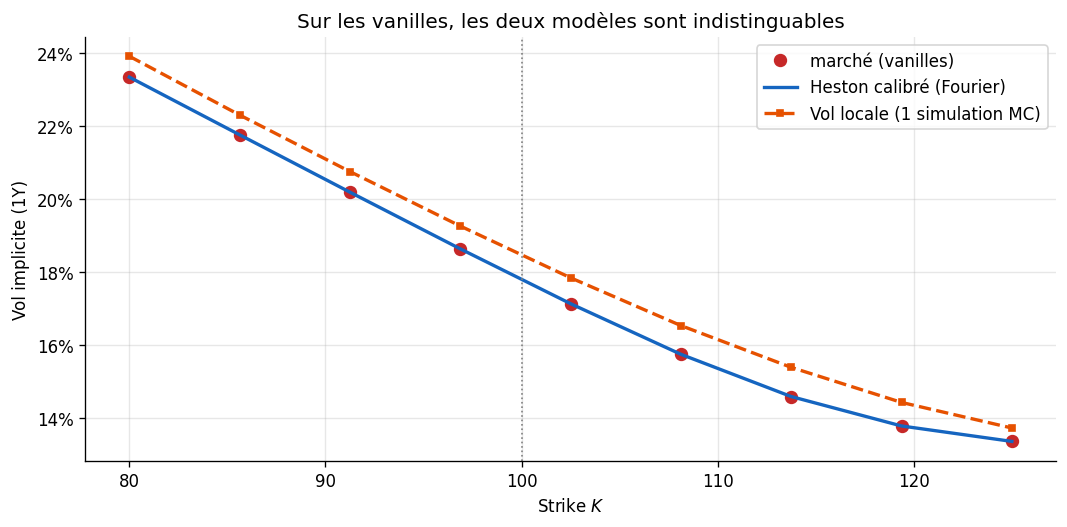

Écart max Heston vs marché : 0.0 bps
Écart max LV vs marché     : 80.0 bps


In [4]:
K_re = np.linspace(80, 125, 9)
mkt_calls = [EuropeanOption(und0, float(K), REF, in_days(365), OptionType.CALL) for K in K_re]
iv_mkt = np.asarray(ivc.calculate_implied_vol(mkt_calls, fourier.price(mkt_calls, heston_true)))
iv_he = np.asarray(ivc.calculate_implied_vol(mkt_calls, fourier.price(mkt_calls, heston)))

df1 = disc.discount(1.0)
ST_lv = terminal_ST(lv, und0, 365, 120_000, 150, seed=1)          # UNE simulation
px_lv = df1 * np.maximum(ST_lv[:, None] - K_re[None, :], 0.0).mean(axis=0)
iv_lv = np.asarray(ivc.calculate_implied_vol(mkt_calls, px_lv))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(K_re, iv_mkt*100, 'o', color=C_MKT, ms=7, label='marché (vanilles)')
ax.plot(K_re, iv_he*100, '-', color=C_HE, lw=2, label='Heston calibré (Fourier)')
ax.plot(K_re, iv_lv*100, 's--', color=C_LV, lw=2, ms=4, label='Vol locale (1 simulation MC)')
ax.axvline(S0, color='grey', ls=':', lw=1)
ax.set_xlabel('Strike $K$'); ax.set_ylabel('Vol implicite (1Y)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Sur les vanilles, les deux modèles sont indistinguables'); ax.legend()
plt.tight_layout(); plt.show()
print('Écart max Heston vs marché :', round(np.max(np.abs(iv_he-iv_mkt))*1e4, 1), 'bps')
print('Écart max LV vs marché     :', round(np.max(np.abs(iv_lv-iv_mkt))*1e4, 1), 'bps')

## 2. Divergence : un call à barrière (up-and-out)

Un **up-and-out call** (strike 100, barrière au-dessus, monitoring hebdomadaire, 1Y)
est *knock-outé* si le spot franchit la barrière. Payoff **path-dependent** : son prix
dépend de la **dynamique** près de la barrière, pas seulement de la loi terminale. Les
deux modèles, simulés sur la **même grille** hebdomadaire, divergent.

 barrière        LV    Heston    écart  écart %
      110    0.3513    0.6523  -0.3010   -46.2%
      115    1.3561    2.1254  -0.7693   -36.2%
      120    3.1349    4.0723  -0.9374   -23.0%
      130    6.7632    7.0258  -0.2625    -3.7%
      140    8.2157    8.0649  +0.1508    +1.9%


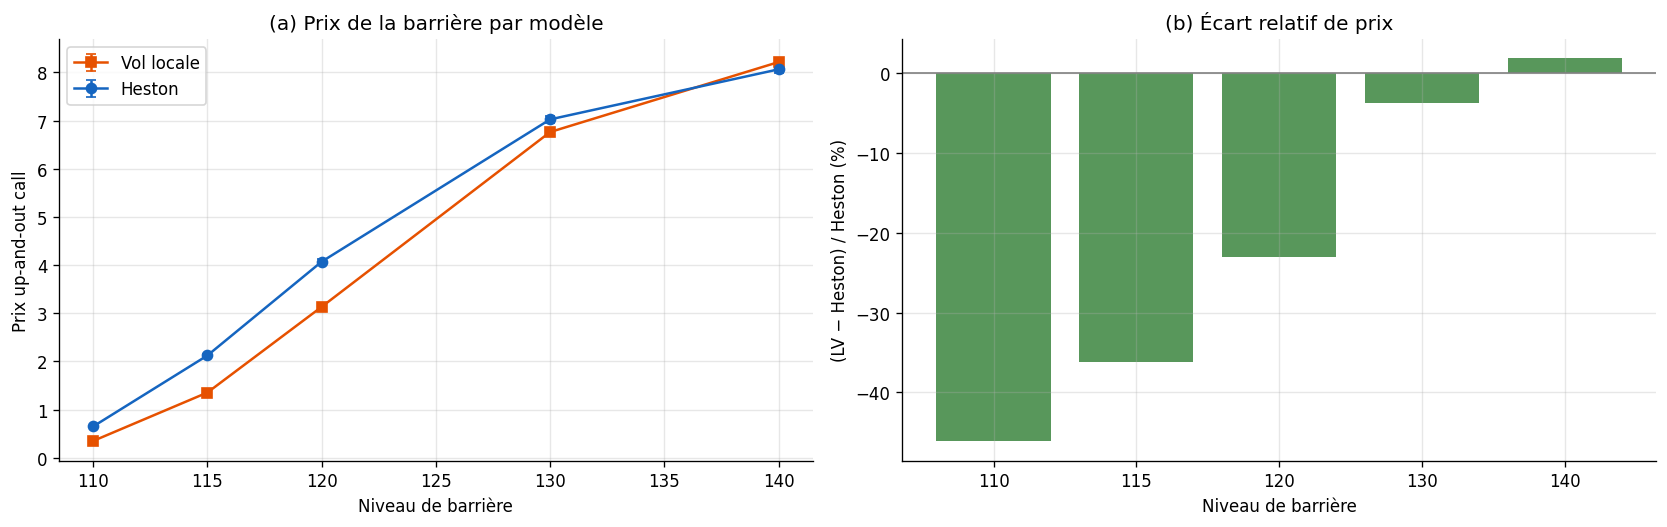

In [5]:
def barrier_uo_call(level):
    return BarrierOption(und0, K=100.0, start_date=REF, maturity_date=in_days(365),
                         frequency=Frequency.WEEKLY, option_type=OptionType.CALL,
                         barrier_type=BarrierType.OUT, barrier_direction=BarrierDirection.UP,
                         barrier_level=float(level))

# max_dt large -> Heston ne sur-échantillonne pas : monitoring = grille hebdo (comme la LV)
heston_weekly = heston_mc(max_dt=0.1)
levels = [110, 115, 120, 130, 140]
px_lv_b, px_he_b, se_lv_b, se_he_b = [], [], [], []
for lvl in levels:
    b = barrier_uo_call(lvl)
    pl = lv.simulate(b, 50_000, rng=np.random.default_rng(10))
    ph = heston_weekly.simulate(b, 50_000, rng=np.random.default_rng(11))
    px_lv_b.append(pl.mean()); se_lv_b.append(pl.std(ddof=1)/np.sqrt(len(pl)))
    px_he_b.append(ph.mean()); se_he_b.append(ph.std(ddof=1)/np.sqrt(len(ph)))
px_lv_b, px_he_b = np.array(px_lv_b), np.array(px_he_b)
se_lv_b, se_he_b = np.array(se_lv_b), np.array(se_he_b)

print(f"{'barrière':>9}{'LV':>10}{'Heston':>10}{'écart':>9}{'écart %':>9}")
for lvl, a, b in zip(levels, px_lv_b, px_he_b):
    print(f"{lvl:>9}{a:>10.4f}{b:>10.4f}{a-b:>+9.4f}{(a/b-1)*100:>+8.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.errorbar(levels, px_lv_b, yerr=1.96*se_lv_b, fmt='s-', color=C_LV, capsize=3, label='Vol locale')
ax.errorbar(levels, px_he_b, yerr=1.96*se_he_b, fmt='o-', color=C_HE, capsize=3, label='Heston')
ax.set_xlabel('Niveau de barrière'); ax.set_ylabel('Prix up-and-out call')
ax.set_title('(a) Prix de la barrière par modèle'); ax.legend()
ax = axes[1]
ax.bar([str(l) for l in levels], (px_lv_b/px_he_b-1)*100, color=C_SK, alpha=.8)
ax.axhline(0, color='grey', lw=1)
ax.set_xlabel('Niveau de barrière'); ax.set_ylabel('(LV − Heston) / Heston (%)')
ax.set_title('(b) Écart relatif de prix')
plt.tight_layout(); plt.show()

## 3. Contre-point : la digitale est ~identique

Une **digitale cash** (paie 1 si $S_T>K$) est un payoff **européen** : son prix ne
dépend que de la **loi terminale**, donc du seul **skew d'aujourd'hui** — que les deux
modèles partagent. On les reprice à partir des $S_T$ déjà simulés (LV) et d'une
simulation terminale Heston. Ils s'accordent **aux résidus de repricing/MC près** (le
même petit écart que sur les vanilles, accentué dans les ailes) — sans commune mesure
avec la divergence de la barrière. La barrière diverge à cause de la **dynamique** ;
la digitale, payoff terminal, non.

     K   digit. LV  digit. Heston     écart
    90      0.7658         0.7720   -0.0062
    95      0.6964         0.7057   -0.0093
   100      0.6098         0.6182   -0.0084
   105      0.5040         0.5086   -0.0046
   110      0.3830         0.3802   +0.0028


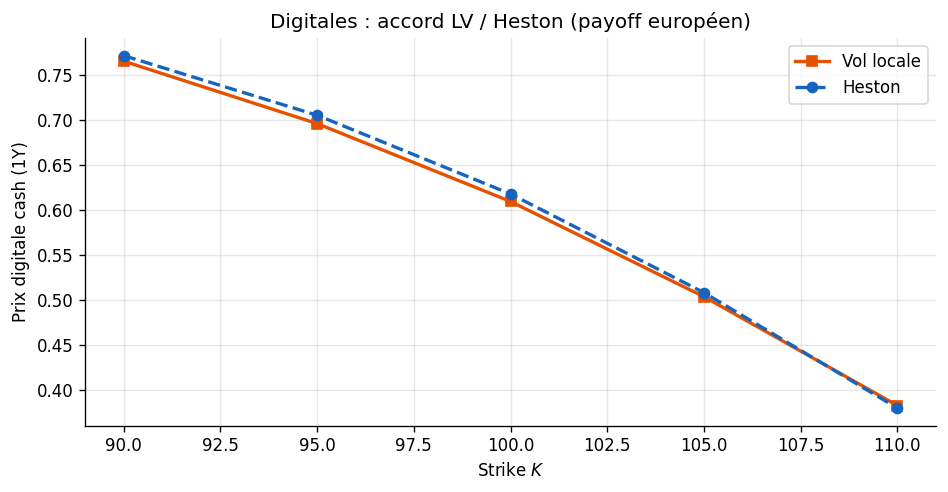

In [6]:
ST_he = terminal_ST(heston_mc(1/52), und0, 365, 120_000, 1, seed=21)  # Heston densifie via max_dt
Kd = np.array([90, 95, 100, 105, 110], dtype=float)
dig_lv = df1 * (ST_lv[:, None] > Kd[None, :]).mean(axis=0)   # réutilise ST_lv du §1
dig_he = df1 * (ST_he[:, None] > Kd[None, :]).mean(axis=0)

print(f"{'K':>6}{'digit. LV':>12}{'digit. Heston':>15}{'écart':>10}")
for K, a, b in zip(Kd, dig_lv, dig_he):
    print(f"{K:>6.0f}{a:>12.4f}{b:>15.4f}{a-b:>+10.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(Kd, dig_lv, 's-', color=C_LV, lw=2, label='Vol locale')
ax.plot(Kd, dig_he, 'o--', color=C_HE, lw=2, label='Heston')
ax.set_xlabel('Strike $K$'); ax.set_ylabel('Prix digitale cash (1Y)')
ax.set_title('Digitales : accord LV / Heston (payoff européen)'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Le pourquoi : comment le smile bouge quand le spot bouge

C'est le cœur. On déplace le spot et on regarde la **vol implicite ATM** (au strike
$K=S$) prédite par chaque hypothèse de dynamique :

- **Sticky-strike** : la vol à *strike fixe* ne bouge pas → la vol ATM glisse le long du
  smile d'aujourd'hui (pente ≈ skew).
- **Heston** (vol stochastique) : le smile **flotte** avec le spot → vol ATM ~**constante**
  (*sticky-moneyness*).
- **Vol locale** : la surface $\sigma_{\rm loc}(K,t)$ est **figée** en absolu → la vol ATM
  bouge d'environ **2× le skew**, à **contre-sens** de ce qu'on observe en pratique.

Pour la LV on **gèle** la vol locale d'aujourd'hui (`FrozenLV`) et on rediffuse depuis
chaque spot (une simulation par spot). Pour Heston on reprice par Fourier au spot
déplacé.

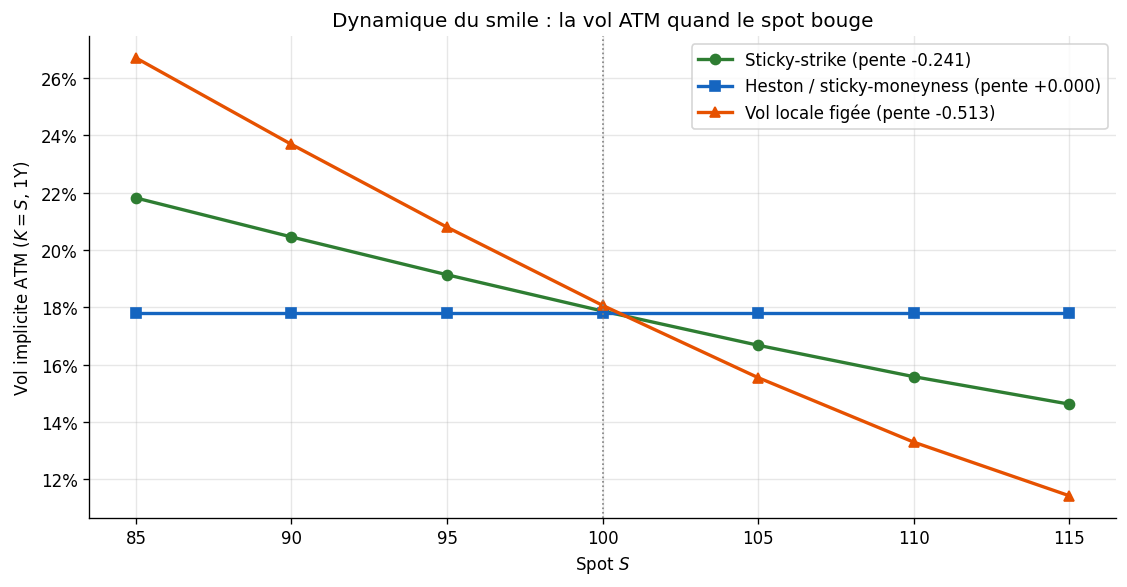

Pente de la vol ATM (%/pt de spot) :
  sticky-strike : -0.241
  Heston        : +0.000  (~plat = sticky-moneyness)
  vol locale    : -0.513  (~2x le skew, a contre-sens)


In [7]:
flv = FrozenLV(disc, surface, fwd0)
spots = np.array([85, 90, 95, 100, 105, 110, 115], dtype=float)
iv_sticky, iv_heston, iv_localvol = [], [], []
for Sb in spots:
    spotb = Quote(float(Sb)); fwdb = AnalyticForwardCurve(spotb, disc, 0.0)
    undb = Underlying('EQ', spotb, fwdb, surface)
    callref = EuropeanOption(undb, float(Sb), REF, in_days(365), OptionType.CALL)
    # sticky-strike : smile d'aujourd'hui lu au strike = nouveau spot
    iv_sticky.append(float(surface.sigma(float(Sb), 1.0)))
    # Heston : reprice ATM au spot déplacé (Fourier)
    iv_heston.append(float(ivc.calculate_implied_vol([callref], fourier.price([callref], heston))[0]))
    # Vol locale figée : une rediffusion MC depuis le spot déplacé (ATM)
    STb = flv.simulate(TerminalSpots(undb, float(Sb), REF, in_days(365), OptionType.CALL, n_steps=60),
                       40_000, rng=np.random.default_rng(30)) / df1
    px = df1 * np.maximum(STb - float(Sb), 0.0).mean()
    iv_localvol.append(float(ivc.calculate_implied_vol([callref], [px])[0]))
iv_sticky, iv_heston, iv_localvol = map(np.array, (iv_sticky, iv_heston, iv_localvol))

def slope(y): return np.polyfit(spots, y, 1)[0] * 100  # %/pt de spot

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(spots, iv_sticky*100, 'o-', color=C_SK, lw=2, label=f'Sticky-strike (pente {slope(iv_sticky):+.3f})')
ax.plot(spots, iv_heston*100, 's-', color=C_HE, lw=2, label=f'Heston / sticky-moneyness (pente {slope(iv_heston):+.3f})')
ax.plot(spots, iv_localvol*100, '^-', color=C_LV, lw=2, label=f'Vol locale figée (pente {slope(iv_localvol):+.3f})')
ax.axvline(S0, color='grey', ls=':', lw=1)
ax.set_xlabel('Spot $S$'); ax.set_ylabel('Vol implicite ATM ($K=S$, 1Y)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Dynamique du smile : la vol ATM quand le spot bouge'); ax.legend()
plt.tight_layout(); plt.show()

print('Pente de la vol ATM (%/pt de spot) :')
print(f'  sticky-strike : {slope(iv_sticky):+.3f}')
print(f'  Heston        : {slope(iv_heston):+.3f}  (~plat = sticky-moneyness)')
print(f'  vol locale    : {slope(iv_localvol):+.3f}  (~2x le skew, a contre-sens)')

## 5. Récapitulatif — le risque de modèle

| | Vanilles | Digitale | Barrière (path-dependent) |
|---|---|---|---|
| **Heston** | ✓ reprice | ✓ ~identique | **prix A** |
| **Vol locale** | ✓ reprice | ✓ ~identique | **prix B ≠ A** |

- Deux modèles **calibrés sur la même surface** s'accordent sur les payoffs **européens**
  (vanilles, digitales) — ils partagent le skew d'aujourd'hui.
- Ils **divergent** sur un exotique **path-dependent** (la barrière) car ils n'ont pas la
  même **dynamique de smile** :
  - **Heston** : *sticky-moneyness* — le smile flotte, vol ATM quasi constante.
  - **Vol locale** : dynamique **figée / à contre-sens** — vol ATM ~2× le skew.
- **Conséquence pratique** : pour un produit sensible à la dynamique (barrières,
  forward-start, cliquets, autocalls), le choix du modèle **change le prix et la
  couverture**. Calibrer les vanilles ne tranche pas — il faut un modèle dont la
  **dynamique** colle au risque porté.

C'est l'aboutissement de la série : un outil unique permet de **construire le marché**
(03), de **valider la précision** (04), de manier **vol stochastique** (05) et **vol
locale** (06), et enfin de **mesurer le risque de modèle** sur un exotique (07).